# Final Model -- DenseNet-121 + MLP (200-100-50, regularized)

Streamlined version of `Basic_CNN_model.ipynb` for a single, final model instead of
the many architectures/experiments compared there. Everything through image loading,
hair removal, cropping and augmentation is the same pipeline as that notebook. From
there this notebook differs in three ways:

- **Split**: uses the pre-defined `training_set.csv` / `validation_set.csv` (image
  IDs only) instead of computing a fresh `StratifiedGroupKFold` split.
- **Images**: only the cropped (`boundary_localization_crop`) images are used --
  no 'original'/'hairless'/'cleaned' comparison.
- **Model**: DenseNet-121 (frozen) + a 200 -> 100 -> 50 MLP head, with Dropout and
  L2 regularization on every Dense layer. `DROPOUT_RATE` / `L2_STRENGTH` below are
  left at reasonable defaults -- tune them from here.

Ends by saving each split's predicted probabilities to `outputs/`, keyed by
`image_name`, for downstream evaluation/submission.

In [1]:
import os
import random

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Fix every source of randomness up front so metrics (val_recall etc.) are
# reproducible run-to-run -- numpy/sklearn seeds are pinned per-call below
# (random_state=42, seed=42), and TensorFlow's own RNG (Dense-layer weight
# init) plus GPU op-level determinism need pinning separately: cuDNN
# convolution/reduction algorithms pick a nondeterministic implementation
# by default otherwise.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

## (Colab only) Unpack data from Google Drive

Running on a local kernel, `train/` and `train_labels.csv` already sit next to this
notebook. Running on a **Colab kernel**, upload `melanoma_data.zip` to your Google
Drive once, then this cell mounts your Drive and unzips it into `/content` each
session (falls back to a directly-uploaded `/content/melanoma_data.zip`). No-op
when there's no Colab runtime.

In [2]:
import os

if os.path.isdir('/content'):
    os.chdir('/content')
    if not os.path.isdir('train'):
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'  # adjust if you put it elsewhere in Drive

        from google.colab import drive
        drive.mount('/content/drive')

        zip_source = DRIVE_ZIP_PATH if os.path.exists(DRIVE_ZIP_PATH) else 'melanoma_data.zip'
        assert os.path.exists(zip_source), (
            f"Couldn't find the data zip at {DRIVE_ZIP_PATH} or /content/melanoma_data.zip -- "
            "upload melanoma_data.zip to your Google Drive (or directly to Colab) first"
        )
        get_ipython().system(f'unzip -q "{zip_source}"')
    print('data ready in', os.getcwd())

Mounted at /content/drive
data ready in /content


In [3]:
# VS Code's Jupyter extension can run this notebook with the *workspace root*
# as the working directory instead of this notebook's own folder, which breaks
# every relative path below (train_labels.csv, training_set.csv, train/, ...).
# __vsc_ipynb_file__ (injected by the VS Code Jupyter extension) gives this
# notebook's own absolute path -- hop into its folder if we're not already there
# and we're not on Colab (which manages its own /content working directory above).
import os

_nb_path = globals().get('__vsc_ipynb_file__')
if _nb_path and not os.path.isdir('/content'):
    os.chdir(os.path.dirname(_nb_path))

print('working directory:', os.getcwd())

working directory: /content


## Reading files

In [4]:
import os
import pandas as pd

TRAIN_DIR = 'train'

# sorted() so image order is identical across machines/runs -- os.listdir()
# order is filesystem-dependent and not guaranteed stable
train_files = sorted(f for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg'))
files_df = pd.DataFrame({
    'image_name': [os.path.splitext(f)[0] for f in train_files],
    'image_path': [os.path.join(TRAIN_DIR, f) for f in train_files],
})

print(f'{len(files_df)} jpg files found in {TRAIN_DIR}/')
files_df.head()

6864 jpg files found in train/


,image_name,image_path
0,ISIC_0015719,train/ISIC_0015719.jpg
1,ISIC_0074542,train/ISIC_0074542.jpg
2,ISIC_0076545,train/ISIC_0076545.jpg
3,ISIC_0082348,train/ISIC_0082348.jpg
4,ISIC_0085172,train/ISIC_0085172.jpg


In [5]:
labels_df = pd.read_csv('train_labels.csv')

# join filenames with their labels on image_name
data_df = files_df.merge(labels_df, on='image_name', how='inner')

print(f'{len(data_df)} images matched to a label (of {len(files_df)} files, {len(labels_df)} label rows)')
data_df.shape

6864 images matched to a label (of 6864 files, 6864 label rows)


(6864, 9)

## Image-only dataset (image_name, patient_id, image_path, target)

In [6]:
image_df = data_df[['image_name', 'patient_id', 'image_path', 'target']].copy()
image_df.head()

,image_name,patient_id,image_path,target
0,ISIC_0015719,IP_3075186,train/ISIC_0015719.jpg,0
1,ISIC_0074542,IP_4698288,train/ISIC_0074542.jpg,0
2,ISIC_0076545,IP_9802602,train/ISIC_0076545.jpg,0
3,ISIC_0082348,IP_7684360,train/ISIC_0082348.jpg,0
4,ISIC_0085172,IP_1705144,train/ISIC_0085172.jpg,0


## Hair removal (DullRazor)

Dermoscopy images often have body hair overlaid on the lesion -- noise the model
has no business learning from. This runs the classic **DullRazor** algorithm (a
blackhat morphological filter finds dark, thin, hair-like structures, thresholds
them into a mask, and `cv2.inpaint` fills them back in from surrounding skin) on
the full-resolution image, before any resizing. It's the input the cropping step
below runs on.

In [7]:
import cv2


def remove_hair(img_rgb, kernel_size=9, inpaint_radius=6, thresh=10):
    """
    DullRazor-style hair removal: a blackhat morphological filter highlights
    dark, thin, hair-like structures against the surrounding skin; those pixels
    are thresholded into a mask, and cv2.inpaint fills them back in using the
    surrounding (hair-free) pixels.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blurred = cv2.GaussianBlur(blackhat, (3, 3), cv2.BORDER_DEFAULT)
    _, hair_mask = cv2.threshold(blurred, thresh, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img_rgb, hair_mask, inpaint_radius, cv2.INPAINT_TELEA)

### Cache hair-removed images (skip re-running DullRazor every session)

`remove_hair` (`cv2.inpaint` over ~6864 full-resolution images) is slow. Run it
**once**: every hair-removed image gets written to `train_hairless/`, zipped, and
copied to Google Drive. Later runs (or after a Colab reset) detect the cached zip
and just unzip it instead of reprocessing everything.

In [8]:
import shutil
import zipfile

HAIRLESS_DIR = 'train_hairless'
HAIRLESS_ZIP = 'melanoma_hairless.zip'
DRIVE_HAIRLESS_ZIP = '/content/drive/MyDrive/melanoma_hairless.zip'

# Reuse a previous run's output if it's already sitting locally or in Drive,
# instead of re-running DullRazor on all images again
if not os.path.isdir(HAIRLESS_DIR):
    cached_zip = next((z for z in (HAIRLESS_ZIP, DRIVE_HAIRLESS_ZIP) if os.path.exists(z)), None)
    os.makedirs(HAIRLESS_DIR, exist_ok=True)
    if cached_zip:
        get_ipython().system(f'unzip -q "{cached_zip}" -d "{HAIRLESS_DIR}"')
        print(f'reused cached hair-removed images from {cached_zip}')
    else:
        print(f'no cache found -- run the next cell to generate {HAIRLESS_DIR}/')

reused cached hair-removed images from /content/drive/MyDrive/melanoma_hairless.zip


In [9]:
# Resume-safe: only processes images not already in HAIRLESS_DIR, so re-running
# this cell after an interruption (or once the cache already exists) is cheap
existing = set(os.listdir(HAIRLESS_DIR))
todo = [p for p in image_df['image_path'] if os.path.basename(p) not in existing]

for i, path in enumerate(todo):
    with Image.open(path) as img:
        arr = np.array(img.convert('RGB'))
    cleaned = remove_hair(arr)
    Image.fromarray(cleaned).save(os.path.join(HAIRLESS_DIR, os.path.basename(path)), quality=95)
    if (i + 1) % 500 == 0:
        print(f'{i + 1}/{len(todo)} processed')

print(f'{len(os.listdir(HAIRLESS_DIR))} hair-removed images in {HAIRLESS_DIR}/ '
      f'({len(todo)} newly processed this run)')

6864 hair-removed images in train_hairless/ (0 newly processed this run)


In [10]:
if not os.path.exists(HAIRLESS_ZIP):
    with zipfile.ZipFile(HAIRLESS_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
        for filename in sorted(os.listdir(HAIRLESS_DIR)):
            zf.write(os.path.join(HAIRLESS_DIR, filename), arcname=filename)
    print(f'wrote {HAIRLESS_ZIP} ({os.path.getsize(HAIRLESS_ZIP) / 1e6:.0f} MB)')

if os.path.isdir('/content/drive/MyDrive') and not os.path.exists(DRIVE_HAIRLESS_ZIP):
    shutil.copy(HAIRLESS_ZIP, DRIVE_HAIRLESS_ZIP)
    print('copied to Google Drive as melanoma_hairless.zip -- future sessions will reuse it automatically')

wrote melanoma_hairless.zip (409 MB)


## Boundary localization crop -- only image source used here

This notebook only ever trains on the cropped images (`boundary_localization_crop`
from `boundary_localization.py`, reimplementing Algorithm 1 from Gajera, Nayak &
Zaveri, 2023). `CROPPED_DIR` is restored from a cached zip (local, then Drive) if
one exists; otherwise the next cell generates it from `train_hairless/`.

In [11]:
IMG_SIZE = 224

CROPPED_DIR = 'train_cropped'
CROPPED_ZIP = 'melanoma_cropped.zip'
DRIVE_CROPPED_ZIP = '/content/drive/MyDrive/melanoma_cropped.zip'

os.makedirs(CROPPED_DIR, exist_ok=True)

if not os.listdir(CROPPED_DIR):
    if os.path.isdir('/content') and not os.path.isdir('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')

    cached_zip = next((z for z in (CROPPED_ZIP, DRIVE_CROPPED_ZIP) if os.path.exists(z)), None)
    if cached_zip:
        get_ipython().system(f'unzip -q "{cached_zip}" -d "{CROPPED_DIR}"')
        print(f'reused cached cropped images from {cached_zip}')
    else:
        print(f'no cached {CROPPED_ZIP} found -- the next cell will generate it from {HAIRLESS_DIR}/')
else:
    print(f'{len(os.listdir(CROPPED_DIR))} cropped images already present in {CROPPED_DIR}/')

reused cached cropped images from /content/drive/MyDrive/melanoma_cropped.zip


In [12]:
if not os.listdir(CROPPED_DIR):
    from boundary_localization import boundary_localization_crop

    hairless_filenames = sorted(
        f for f in os.listdir(HAIRLESS_DIR)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    )
    already_done = set(os.listdir(CROPPED_DIR))
    todo = [f for f in hairless_filenames if f not in already_done]
    print(f'{len(hairless_filenames)} hairless images total, {len(todo)} left to crop')

    for i, fname in enumerate(todo):
        with Image.open(os.path.join(HAIRLESS_DIR, fname)) as img:
            image = np.array(img.convert('RGB'))
        roi, _, _ = boundary_localization_crop(image, output_size=IMG_SIZE)
        Image.fromarray(roi).save(os.path.join(CROPPED_DIR, fname))
        if (i + 1) % 500 == 0:
            print(f'{i + 1}/{len(todo)} done')

    with zipfile.ZipFile(CROPPED_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
        for filename in sorted(os.listdir(CROPPED_DIR)):
            zf.write(os.path.join(CROPPED_DIR, filename), arcname=filename)
    print(f'wrote {CROPPED_ZIP} ({os.path.getsize(CROPPED_ZIP) / 1e6:.0f} MB)')

    if os.path.isdir('/content/drive/MyDrive') and not os.path.exists(DRIVE_CROPPED_ZIP):
        shutil.copy(CROPPED_ZIP, DRIVE_CROPPED_ZIP)
        print('copied to Google Drive as melanoma_cropped.zip -- future sessions will reuse it automatically')

In [13]:
def load_images(df, img_size=IMG_SIZE, image_dir=CROPPED_DIR):
    """Loads each row's cropped image (matched to df['image_path'] by filename),
    resized to img_size, alongside its target label."""
    X = np.empty((len(df), img_size, img_size, 3), dtype=np.uint8)
    for i, path in enumerate(df['image_path']):
        source_path = os.path.join(image_dir, os.path.basename(path))
        with Image.open(source_path) as img:
            img = img.convert('RGB').resize((img_size, img_size))
            X[i] = np.array(img)
    y = df['target'].to_numpy()
    return X, y

### Fetch the split files on Colab

`training_set.csv` / `validation_set.csv` aren't bundled in `melanoma_data.zip`,
so on a Colab kernel they won't exist yet even after the data-unpack cell above.
This reuses a copy from Google Drive if you've put one there, otherwise prompts a
direct upload. No-op locally, where they already sit next to this notebook.

In [14]:
SPLIT_FILES = ['training_set.csv', 'validation_set.csv']
DRIVE_SPLIT_DIR = '/content/drive/MyDrive'  # adjust if you put them elsewhere in Drive

if os.path.isdir('/content'):
    missing = [f for f in SPLIT_FILES if not os.path.exists(f)]

    for f in missing:
        drive_copy = os.path.join(DRIVE_SPLIT_DIR, f)
        if os.path.exists(drive_copy):
            shutil.copy(drive_copy, f)
            print(f'copied {f} from Google Drive')

    still_missing = [f for f in SPLIT_FILES if not os.path.exists(f)]
    if still_missing:
        print(f'upload {still_missing} now (or drop copies into {DRIVE_SPLIT_DIR} and re-run this cell):')
        from google.colab import files
        files.upload()

copied training_set.csv from Google Drive
copied validation_set.csv from Google Drive


## Train/validation split -- from `training_set.csv` / `validation_set.csv`

These list `image_name` only (no labels) -- a pre-defined, patient-grouped split
computed once and shared across notebooks, rather than a fresh
`StratifiedGroupKFold` split here. Merge each against `image_df` to attach
`patient_id`/`image_path`/`target`, then sanity-check the split the same way the
original notebook checked its own: no patient split across both sides, every
listed image_name found.

In [15]:
train_ids = pd.read_csv('training_set.csv')
val_ids = pd.read_csv('validation_set.csv')

train_df = image_df.merge(train_ids, on='image_name', how='inner')
test_df = image_df.merge(val_ids, on='image_name', how='inner')

assert len(train_df) == len(train_ids), f"{len(train_ids) - len(train_df)} training_set.csv image_name(s) not found in image_df"
assert len(test_df) == len(val_ids), f"{len(val_ids) - len(test_df)} validation_set.csv image_name(s) not found in image_df"
assert set(train_df['patient_id']) & set(test_df['patient_id']) == set(), 'patient leakage between train/validation!'

print(f'train:      {len(train_df)} images, {train_df["patient_id"].nunique()} patients, {train_df["target"].mean():.2%} malignant')
print(f'validation: {len(test_df)} images, {test_df["patient_id"].nunique()} patients, {test_df["target"].mean():.2%} malignant')

train:      5629 images, 337 patients, 1.83% malignant
validation: 1235 images, 85 patients, 2.02% malignant


In [16]:
X_train, y_train = load_images(train_df)
X_test, y_test = load_images(test_df)

print(X_train.shape, X_train.dtype, f'{X_train.nbytes / 1e6:.0f} MB')
print(X_test.shape, X_test.dtype, f'{X_test.nbytes / 1e6:.0f} MB')

(5629, 224, 224, 3) uint8 847 MB
(1235, 224, 224, 3) uint8 186 MB


## Augmentation function

In [17]:
import albumentations as A
import cv2
import numpy as np

# Same recipe as the exploratory notebook:
# - no HueSaturationValue -- dermoscopy diagnosis leans on pigment color, so
#   hue/saturation shifts risk destroying the exact signal the model should learn.
# - no Resize/Normalize baked in -- images are already IMG_SIZE from load_images,
#   and normalization is handled once, uniformly, by DenseNet's preprocess_input
#   downstream.
# - border_mode=cv2.BORDER_REFLECT_101 on every transform that can expose new
#   pixels, so we mirror the lesion instead of padding with a black wedge the
#   model could key off as a non-diagnostic shortcut.
# - no distortion (Optical/Grid/Elastic) and no zoom (scale_limit=0 in
#   ShiftScaleRotate) -- images are already tightly cropped to the lesion, so
#   warping/zooming risks cutting off the lesion edge or exaggerating its size.
# - CoarseDropout box kept small (10-20% of the image, not ~37.5%) -- with only
#   ~100 original malignant images, blacking out most of the lesion risks
#   generating "malignant" copies that just show healthy skin.
melanoma_augment = A.Compose([
    A.Transpose(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(std_range=(0.02, 0.08)),
    ], p=0.7),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=15,
                        border_mode=cv2.BORDER_REFLECT_101, p=0.85),
    A.CoarseDropout(num_holes_range=(1, 1),
                     hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2),
                     p=0.5),
])

def augment_minority_class(images, labels, target_class=1, n_target=None, seed=42):
    """
    Generates augmented copies of images belonging to `target_class` to help
    balance the dataset. Only call this on a TRAINING split -- never on
    validation/test folds.
    """
    rng = np.random.default_rng(seed)

    minority_mask = labels == target_class
    minority_imgs = images[minority_mask]
    n_minority = len(minority_imgs)

    if n_target is None:
        n_majority = len(labels) - n_minority
        n_target = n_majority

    n_to_generate = max(0, n_target - n_minority)

    aug_images = []
    for _ in range(n_to_generate):
        idx = rng.integers(0, n_minority)
        src_img = minority_imgs[idx]
        augmented = melanoma_augment(image=src_img)['image']
        aug_images.append(augmented)

    aug_images = np.array(aug_images) if aug_images else np.empty((0, *images.shape[1:]))
    aug_labels = np.full(len(aug_images), target_class)

    return aug_images, aug_labels

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [18]:
# Target an 80/20 benign/malignant split in the augmented training set -- oversampling
# all the way to 50/50 duplicates each malignant image so many times the model
# memorizes those specific lesions instead of generalizing. The remaining imbalance
# after this lighter oversampling is covered by class_weight during training instead
# of further duplication.
target_minority_ratio = 0.2
n_majority = (y_train == 0).sum()
n_target_minority = int(round(n_majority * target_minority_ratio / (1 - target_minority_ratio)))

aug_imgs, aug_labels = augment_minority_class(X_train, y_train, target_class=1, n_target=n_target_minority)

X_train_balanced = np.concatenate([X_train, aug_imgs], axis=0)
y_train_balanced = np.concatenate([y_train, aug_labels], axis=0)

print(f'train (pre-augmentation): benign={(y_train == 0).sum()}, malignant={(y_train == 1).sum()}, total={len(y_train)}')
print(f'validation:               benign={(y_test == 0).sum()}, malignant={(y_test == 1).sum()}, total={len(y_test)}')
print(f'after augmentation, train_balanced: benign={(y_train_balanced == 0).sum()}, '
      f'malignant={(y_train_balanced == 1).sum()}, total={len(y_train_balanced)}')

train (pre-augmentation): benign=5526, malignant=103, total=5629
validation:               benign=1210, malignant=25, total=1235
after augmentation, train_balanced: benign=5526, malignant=1382, total=6908


## Visualize augmented images

Sanity-check that `melanoma_augment` still produces recognizable lesions.

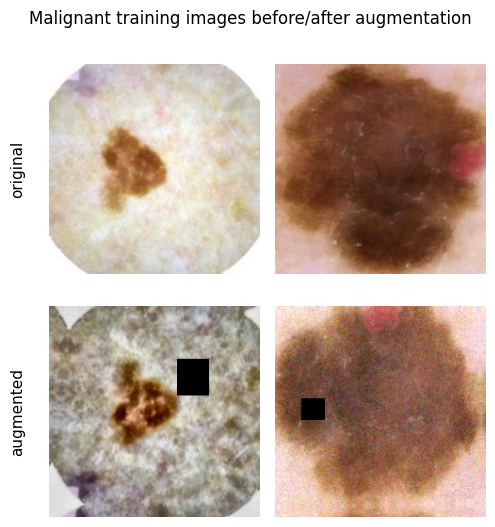

In [19]:
n_show = 2
minority_train_imgs = X_train[y_train == 1]

rng_vis = np.random.default_rng(0)
sample_idx = rng_vis.choice(len(minority_train_imgs), size=n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(2.5 * n_show, 5.5))
for col, idx in enumerate(sample_idx):
    orig = minority_train_imgs[idx]
    augmented = melanoma_augment(image=orig)['image']

    axes[0, col].imshow(orig)
    axes[0, col].axis('off')
    axes[1, col].imshow(augmented)
    axes[1, col].axis('off')

axes[0, 0].text(-0.15, 0.5, 'original', transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=11)
axes[1, 0].text(-0.15, 0.5, 'augmented', transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=11)

fig.suptitle('Malignant training images before/after augmentation')
plt.tight_layout()
plt.show()

## Final model -- DenseNet-121 (frozen) + MLP head (200 -> 100 -> 50)

Dropout and L2 regularization on every Dense layer in the head.
`DROPOUT_RATE` / `L2_STRENGTH` are starting points -- tune from here.

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def make_preprocessed_dataset(images, labels=None, batch_size=32, shuffle=False):
    """
    Streams `images` through DenseNet's preprocess_input in batches instead of
    converting the whole uint8 array to float32 up front -- doing that for
    X_train_balanced needs several GB in one array, enough to OOM-crash a
    free-tier Colab runtime.
    """
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(images)
        prep = lambda x: preprocess_input(tf.cast(x, tf.float32))
    else:
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        prep = lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)

    if shuffle:
        ds = ds.shuffle(len(images), seed=SEED, reshuffle_each_iteration=True)

    return ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)


def plot_training_history(history, title):
    metrics = ['loss', 'auc', 'precision', 'recall']
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(history.history[metric], label='train')
        ax.plot(history.history[f'val_{metric}'], label='val')
        ax.set_title(metric)
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# class_weight makes up the imbalance still remaining in y_train_balanced after the
# lighter (80/20) oversampling above, by weighting the loss instead of duplicating
# more images
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_balanced), y=y_train_balanced)
class_weight_dict = dict(enumerate(class_weights))
print('class_weight:', class_weight_dict)

class_weight: {0: np.float64(0.6250452406804198), 1: np.float64(2.499276410998553)}


In [21]:
DROPOUT_RATE = 0.3  # tune later
L2_STRENGTH = 1e-4  # tune later

def build_final_model(dropout_rate=DROPOUT_RATE, l2_strength=L2_STRENGTH):
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = False  # frozen backbone -- only the MLP head trains

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs)

    h = layers.Dense(200, kernel_regularizer=tf.keras.regularizers.l2(l2_strength))(x)
    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Dropout(dropout_rate)(h)

    h = layers.Dense(100, kernel_regularizer=tf.keras.regularizers.l2(l2_strength))(h)
    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Dropout(dropout_rate)(h)

    h = layers.Dense(50, kernel_regularizer=tf.keras.regularizers.l2(l2_strength))(h)
    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Dropout(dropout_rate)(h)

    outputs = layers.Dense(1, activation='sigmoid')(h)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
    )
    return model

final_model = build_final_model()
final_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       205,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,269,105 (27.73 MB)

 Trainable params: 230,901 (901.96 KB)

 Non-trainable params: 7,038,204 (26.85 MB)

In [22]:
final_train_ds = make_preprocessed_dataset(X_train_balanced, labels=y_train_balanced, batch_size=32, shuffle=True)
final_val_ds = make_preprocessed_dataset(X_test, labels=y_test, batch_size=32)

final_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True)
]

final_history = final_model.fit(
    final_train_ds,
    validation_data=final_val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=final_callbacks,
)

Epoch 1/15
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.5790 - auc: 0.8139 - loss: 0.6327 - precision: 0.3059 - recall: 0.8698 - val_accuracy: 0.8737 - val_auc: 0.6974 - val_loss: 0.5150 - val_precision: 0.0828 - val_recall: 0.5200
Epoch 2/15
216/216 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.7889 - auc: 0.9222 - loss: 0.4312 - precision: 0.4850 - recall: 0.8915 - val_accuracy: 0.9012 - val_auc: 0.7516 - val_loss: 0.4224 - val_precision: 0.1120 - val_recall: 0.5600
Epoch 3/15
216/216 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.8633 - auc: 0.9427 - loss: 0.3568 - precision: 0.6092 - recall: 0.8842 - val_accuracy: 0.9304 - val_auc: 0.7982 - val_loss: 0.3282 - val_precision: 0.1412 - val_recall: 0.4800
Epoch 4/15
216/216 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.9066 - auc: 0.9543 - loss: 0.3137 - precision: 0.7149 - recall: 0.8871 - val_accuracy: 0.9377 - val_auc: 0.8102 - val_loss: 0.2918 - val_precision: 0.1286 - val_recall: 0.3600
Epoch 5/15
216/216 ━━━━

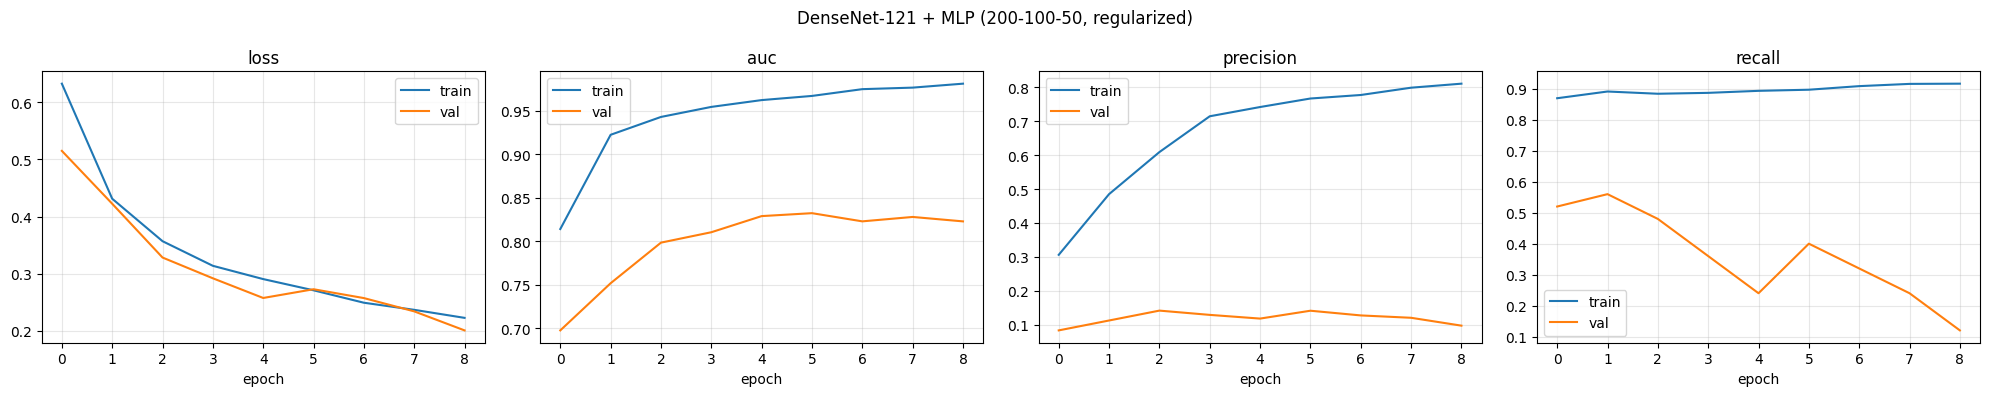

In [23]:
plot_training_history(final_history, "DenseNet-121 + MLP (200-100-50, regularized)")

### Validation predictions (threshold 0.2)

Fixed at 0.2 to match the rest of the project's imbalance-aware evaluation --
adjust once you start tuning `DROPOUT_RATE`/`L2_STRENGTH`.

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step
              precision    recall  f1-score   support

      benign       0.99      0.74      0.85      1210
   malignant       0.06      0.76      0.11        25

    accuracy                           0.74      1235
   macro avg       0.53      0.75      0.48      1235
weighted avg       0.97      0.74      0.83      1235



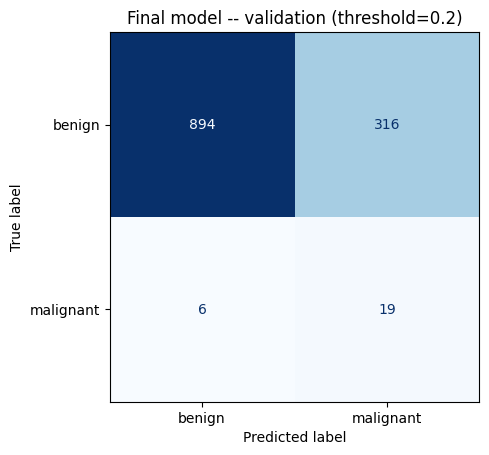

In [24]:
EVAL_THRESHOLD = 0.2

val_y_prob = final_model.predict(make_preprocessed_dataset(X_test)).ravel()
val_y_pred = (val_y_prob >= EVAL_THRESHOLD).astype(int)

print(classification_report(y_test, val_y_pred, target_names=['benign', 'malignant']))

cm = confusion_matrix(y_test, val_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant'])
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'Final model -- validation (threshold={EVAL_THRESHOLD})')
plt.show()

## Save predictions (image ID + probability)

One row per image: `image_name` and the model's raw predicted probability
(no threshold applied), for both splits.

In [25]:
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_y_prob = final_model.predict(make_preprocessed_dataset(X_train)).ravel()
# val_y_prob already computed above

train_predictions = pd.DataFrame({'image_name': train_df['image_name'].to_numpy(), 'probability': train_y_prob})
val_predictions = pd.DataFrame({'image_name': test_df['image_name'].to_numpy(), 'probability': val_y_prob})

train_predictions.to_csv(os.path.join(OUTPUT_DIR, 'train_predictions.csv'), index=False)
val_predictions.to_csv(os.path.join(OUTPUT_DIR, 'validation_predictions.csv'), index=False)

print(f'saved {len(train_predictions)} train predictions -> {OUTPUT_DIR}/train_predictions.csv')
print(f'saved {len(val_predictions)} validation predictions -> {OUTPUT_DIR}/validation_predictions.csv')
val_predictions.head()

176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step
saved 5629 train predictions -> outputs/train_predictions.csv
saved 1235 validation predictions -> outputs/validation_predictions.csv


,image_name,probability
0,ISIC_0082348,0.064600
1,ISIC_0109869,0.129595
2,ISIC_0179191,0.070779
3,ISIC_0192419,0.066767
4,ISIC_0196399,0.951879
